In [4]:
# Setup and package imports 
import mlflow
from pyspark.ml import Pipeline
from pyspark.ml.feature import (
    StringIndexer, OneHotEncoder,
    VectorAssembler, MinMaxScaler
)
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator
from pyspark.ml.evaluation import BinaryClassificationEvaluator

StatementMeta(, 7e90c7a8-551d-4def-a191-11d2d9736e04, 7, Finished, Available, Finished, False)

In [2]:
mlflow.end_run()

StatementMeta(, 7e90c7a8-551d-4def-a191-11d2d9736e04, 5, Finished, Available, Finished, False)

In [5]:
from pyspark.sql import functions as F
# -------------------------------------------
# a. Read Dataset and create Spark DataFrame
# -------------------------------------------
"""feature = [
    'type',
    'amount', 
    'orig_balance_diff', 
    'dest_balance_diff', 
    'orig_zero', 
    'dest_zero', 
    'amount_to_balance', 
    'orig_name_freq', 
    'dest_name_freq', 
    'pair_freq',
    'isFraud'
]"""
spark_df = spark.read.table('FraudDetection.dbo.silver_data_for_MLmodel')#.select(features)
#display( spark_df.limit(5) )


"""ratio =  43956/ 27470#2098272

spark_df = spark_df.withColumn(
    
    "weight",
    F.when(spark_df.isFraud == 1, ratio).otherwise(1.0)
)"""


StatementMeta(, 7e90c7a8-551d-4def-a191-11d2d9736e04, 8, Finished, Available, Finished, False)

'ratio =  43956/ 27470#2098272\n\nspark_df = spark_df.withColumn(\n    \n    "weight",\n    F.when(spark_df.isFraud == 1, ratio).otherwise(1.0)\n)'

In [6]:
# ** 4. Train / Test Split **
# ** 4. Train / Test Split **
#train_df, test_df = spark_df.randomSplit([0.8, 0.2], seed=42)


fractions = {0: 0.8, 1: 0.8}  # keep proportions

train_df = spark_df.stat.sampleBy("isFraud", fractions=fractions, seed=42)

test_df = spark_df.subtract(train_df)

train_df.cache()
test_df.cache()

StatementMeta(, 7e90c7a8-551d-4def-a191-11d2d9736e04, 9, Finished, Available, Finished, False)

DataFrame[step: bigint, type: string, amount: double, oldbalanceOrg: double, newbalanceOrig: double, oldbalanceDest: double, newbalanceDest: double, isFraud: bigint, orig_balance_diff: double, dest_balance_diff: double, orig_zero: int, dest_zero: int, log_amount: double, amount_to_balance: double, orig_error: int, dest_error: int, orig_name_type: string, dest_name_type: string, orig_name_freq: bigint, dest_name_freq: bigint, pair_freq: bigint, balance_ratio_orig: double, balance_ratio_dest: double, abs_orig_diff: double, abs_dest_diff: double, amount_vs_orig: double, amount_vs_dest: double, orig_zero_flag: int, dest_zero_flag: int, hour: bigint, is_night: int, sqrt_amount: double, log_balance_orig: double, log_balance_dest: double]

In [1]:
%run /ml_common

StatementMeta(, 2088ec05-45b3-43cf-9f11-0e4248683051, 8, Finished, Available, Finished, True)

In [8]:
# -----------------------------------------
# 0. Get categorical and numerical features
# --------------------------------------------
label_col = "isFraud" 
categorical_cols, numeric_cols = auto_detect_colum_type(spark_df, label_col)

# **1. Preprocessing the pipeline** 
# ---------------------------------------
# 1.1 Encode categorical freatures 
# --------------------------------------
indexers, encoders = encode_categorical_features(categorical_cols)

# -------------------------------------------------------
# 1.2 Assemble features 
# ----------------------------
assembler_inputs = [f"{c}_ohe" for c in categorical_cols] + numeric_cols

assembler = VectorAssembler(
    inputCols=assembler_inputs,
    outputCol="features_raw"
)

# ----------------------------
# 1.3 Scaling: MimMax scaling 
# ----------------------------
scaler = MinMaxScaler(
    inputCol="features_raw",
    outputCol="features"
)


lr = LogisticRegression(
    featuresCol="features",
    labelCol=label_col
   # weightCol='weight'
)


# **3. Define MLflow pipeline **
pipeline = Pipeline(
    stages=[
        *indexers,
        *encoders,
        assembler,
        scaler,
        lr
    ]
)

# ** 4. Hyperparamer tunning, evaluation and model validation **
paramGrid = hyperparameter_tunning(lr, 'LogisticRegression')

# ** 5. Evaluate and validate the model **
evaluator, cv = evaluate_and_validate(label_col, pipeline, paramGrid)

StatementMeta(, 7e90c7a8-551d-4def-a191-11d2d9736e04, 16, Finished, Available, Finished, False)

Categorical: ['type', 'orig_name_type', 'dest_name_type']
Numeric: ['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'orig_balance_diff', 'dest_balance_diff', 'orig_zero', 'dest_zero', 'log_amount', 'amount_to_balance', 'orig_error', 'dest_error', 'orig_name_freq', 'dest_name_freq', 'pair_freq', 'balance_ratio_orig', 'balance_ratio_dest', 'abs_orig_diff', 'abs_dest_diff', 'amount_vs_orig', 'amount_vs_dest', 'orig_zero_flag', 'dest_zero_flag', 'hour', 'is_night', 'sqrt_amount', 'log_balance_orig', 'log_balance_dest']


In [9]:
# -----------------------------------
# 4. MLflow tracking (Fabric auto-integrated)
# -----------------------------------
mlflow.set_experiment("fabric_spark_logreg")

with mlflow.start_run():

    model = cv.fit(train_df)

    best_model = model.bestModel

    # Log best params manually
    best_lr = best_model.stages[-1]

    mlflow.log_param("regParam", best_lr._java_obj.getRegParam())
    mlflow.log_param("elasticNetParam", best_lr._java_obj.getElasticNetParam())
    mlflow.log_param("maxIter", best_lr._java_obj.getMaxIter())

    # Evaluate
    preds = best_model.transform(test_df)
    auc = evaluator.evaluate(preds)

    mlflow.log_metric("AUC", auc)

    print("Best AUC:", auc)
    

StatementMeta(, 7e90c7a8-551d-4def-a191-11d2d9736e04, 17, Finished, Available, Finished, False)

Best AUC: 0.5048365873364496


StatementMeta(, b79a69da-52fa-4659-a3a9-7807a7f4e198, 132, Finished, Available, Finished, False)

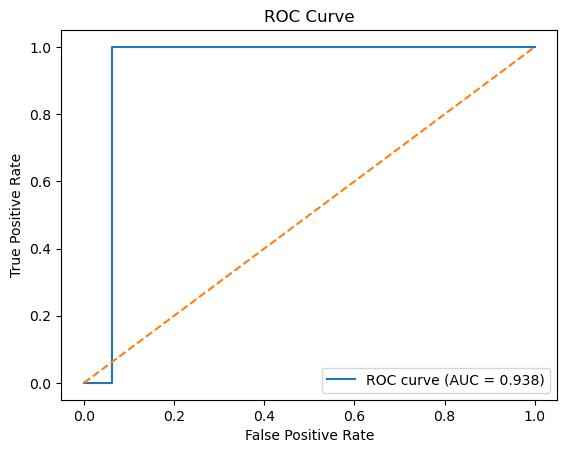

In [ ]:
# ROC curve plot

from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Extract probabilities
preds_pd = preds.toPandas()[["isFraud", "probability"]]
preds_pd["prob"] = preds_pd["probability"].apply(lambda x: x[1])

fpr, tpr, thresholds = roc_curve(preds_pd["isFraud"], preds_pd["prob"])
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()